In [1]:
!pip install -q ultralytics

In [2]:
import os
import yaml
import random
import shutil
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt

import torch

from ultralytics import YOLO

In [3]:
print("="*60)

print("PyTorch :", torch.__version__)

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

else:

    print("Running on CPU")

print("="*60)

PyTorch : 2.10.0+cu128
CUDA Available : True
GPU : Tesla T4


In [4]:
import os

print(os.listdir("/kaggle"))

['lib', 'input', 'working']


In [5]:
from pathlib import Path

for p in Path("/kaggle/input").iterdir():
    print(p)

/kaggle/input/datasets


In [6]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [7]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

In [8]:
from pathlib import Path

DATASET_ROOT = Path(
    "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed"
)

In [9]:
# ============================================================
# Verify Dataset
# ============================================================

assert DATASET_ROOT.exists()

assert (DATASET_ROOT/"images/train").exists()
assert (DATASET_ROOT/"images/val").exists()
assert (DATASET_ROOT/"images/test").exists()

assert (DATASET_ROOT/"labels/train").exists()
assert (DATASET_ROOT/"labels/val").exists()
assert (DATASET_ROOT/"labels/test").exists()

print("✅ Dataset Verified Successfully")

✅ Dataset Verified Successfully


In [10]:
# ============================================================
# Create YAML
# ============================================================

yaml_data = {

    "path": str(DATASET_ROOT),

    "train": "images/train",

    "val": "images/val",

    "test": "images/test",

    "nc": 1,

    "names": ["object"]

}

yaml_path = "/kaggle/working/sku110k.yaml"

with open(yaml_path,"w") as f:

    yaml.dump(yaml_data,f)

print("YAML Created Successfully")

YAML Created Successfully


In [11]:
with open(yaml_path) as f:

    print(f.read())

names:
- object
nc: 1
path: /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed
test: images/test
train: images/train
val: images/val



In [12]:
# ============================================================
# Training Configuration
# ============================================================

MODEL = "yolov8n.pt"

EPOCHS = 10

IMG_SIZE = 416

BATCH_SIZE = 4

WORKERS = 2

PATIENCE = 5

In [13]:
# ============================================================
# Load YOLO Model
# ============================================================

model = YOLO(MODEL)

print("YOLOv8 Nano Loaded Successfully")

YOLOv8 Nano Loaded Successfully


In [14]:
# ============================================================
# Train YOLOv8n
# ============================================================

results = model.train(

    data=yaml_path,

    epochs=EPOCHS,

    imgsz=IMG_SIZE,

    batch=BATCH_SIZE,

    workers=WORKERS,

    device=0 if torch.cuda.is_available() else "cpu",

    patience=PATIENCE,

    cache=True,

    amp=True,

    cos_lr=True,

    optimizer="AdamW",

    seed=SEED,

    project="/kaggle/working/RetailBrain_Models",

    name="YOLOv8n_Baseline",

    exist_ok=True

)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/sku110k.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap

In [15]:
# ============================================================
# Load Best Model
# ============================================================

best_model = YOLO(

"/kaggle/working/RetailBrain_Models/YOLOv8n_Baseline/weights/best.pt"

)

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [16]:
# ============================================================
# Model Validation
# ============================================================

metrics = best_model.val(data=yaml_path)

print(metrics)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 946.1±518.5 MB/s, size: 996.3 KB)
val: Scanning /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels/val... 584 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 584/584 546.3it/s 1.1s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 5% ╸─────────── 2/37 3.9s/it 7.6s<2:15WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 8% ╸─────────── 3/37 4.2s/it 13.0s<2:23WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 

In [17]:
# ============================================================
# Evaluation Metrics
# ============================================================

print("="*60)

print("Precision :", metrics.box.mp)

print("Recall :", metrics.box.mr)

print("mAP50 :", metrics.box.map50)

print("mAP50-95 :", metrics.box.map)

print("="*60)

Precision : 0.8449317643707324
Recall : 0.7267953480145043
mAP50 : 0.7719510363107689
mAP50-95 : 0.43134344183267803


In [30]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'yolov8n.pt', 'RetailBrain_Models', 'runs', 'sku110k.yaml', 'yolo26n.pt']


In [31]:
print(os.listdir("/kaggle/working/RetailBrain_Models"))

['YOLOv8n_Baseline']


In [34]:
import os

print(os.listdir("/kaggle/working/runs"))

['detect']


In [35]:
print(os.listdir("/kaggle/working/runs/detect"))

['val']


In [25]:
from pathlib import Path
from IPython.display import Image, display

prediction_folder = Path("/kaggle/runs/detect")

prediction_runs = sorted(prediction_folder.glob("predict*"))

if len(prediction_runs) == 0:
    print("No prediction folder found.")
    print("Run model.predict() first.")
else:
    latest_prediction = prediction_runs[-1]

    prediction_images = list(latest_prediction.glob("*.jpg"))

    print("Prediction Folder :", latest_prediction)
    print("Images :", len(prediction_images))

    for image in prediction_images[:5]:
        display(Image(filename=str(image)))

No prediction folder found.
Run model.predict() first.


In [36]:
# ============================================================
# Prediction
# ============================================================

results = best_model.predict(

    source=str(DATASET_ROOT/"images/val"),

    conf=0.25,

    imgsz=640,

    save=True
)


image 1/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_0.jpg: 640x384 148 objects, 50.0ms
image 2/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_1.jpg: 640x480 158 objects, 51.6ms
image 3/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_10.jpg: 640x384 129 objects, 7.3ms
image 4/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_100.jpg: 640x480 145 objects, 7.0ms
image 5/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_101.jpg: 640x480 104 objects, 6.5ms
image 6/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_102.jpg: 480x640 248 objects, 48.9ms
image 7/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_103.jpg: 640x480 150 objects, 6.9ms
image 8/584 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fi

In [37]:
# ============================================================
# Training Files
# ============================================================

import os

RESULTS = "/kaggle/working/RetailBrain_Models/YOLOv8n_Baseline"

print(os.listdir(RESULTS))

['train_batch1.jpg', 'val_batch0_labels.jpg', 'confusion_matrix.png', 'BoxPR_curve.png', 'val_batch1_labels.jpg', 'labels.jpg', 'val_batch1_pred.jpg', 'confusion_matrix_normalized.png', 'results.png', 'val_batch0_pred.jpg', 'BoxF1_curve.png', 'train_batch2.jpg', 'val_batch2_labels.jpg', 'train_batch0.jpg', 'val_batch2_pred.jpg', 'results.csv', 'BoxR_curve.png', 'BoxP_curve.png', 'weights', 'args.yaml']


results.png


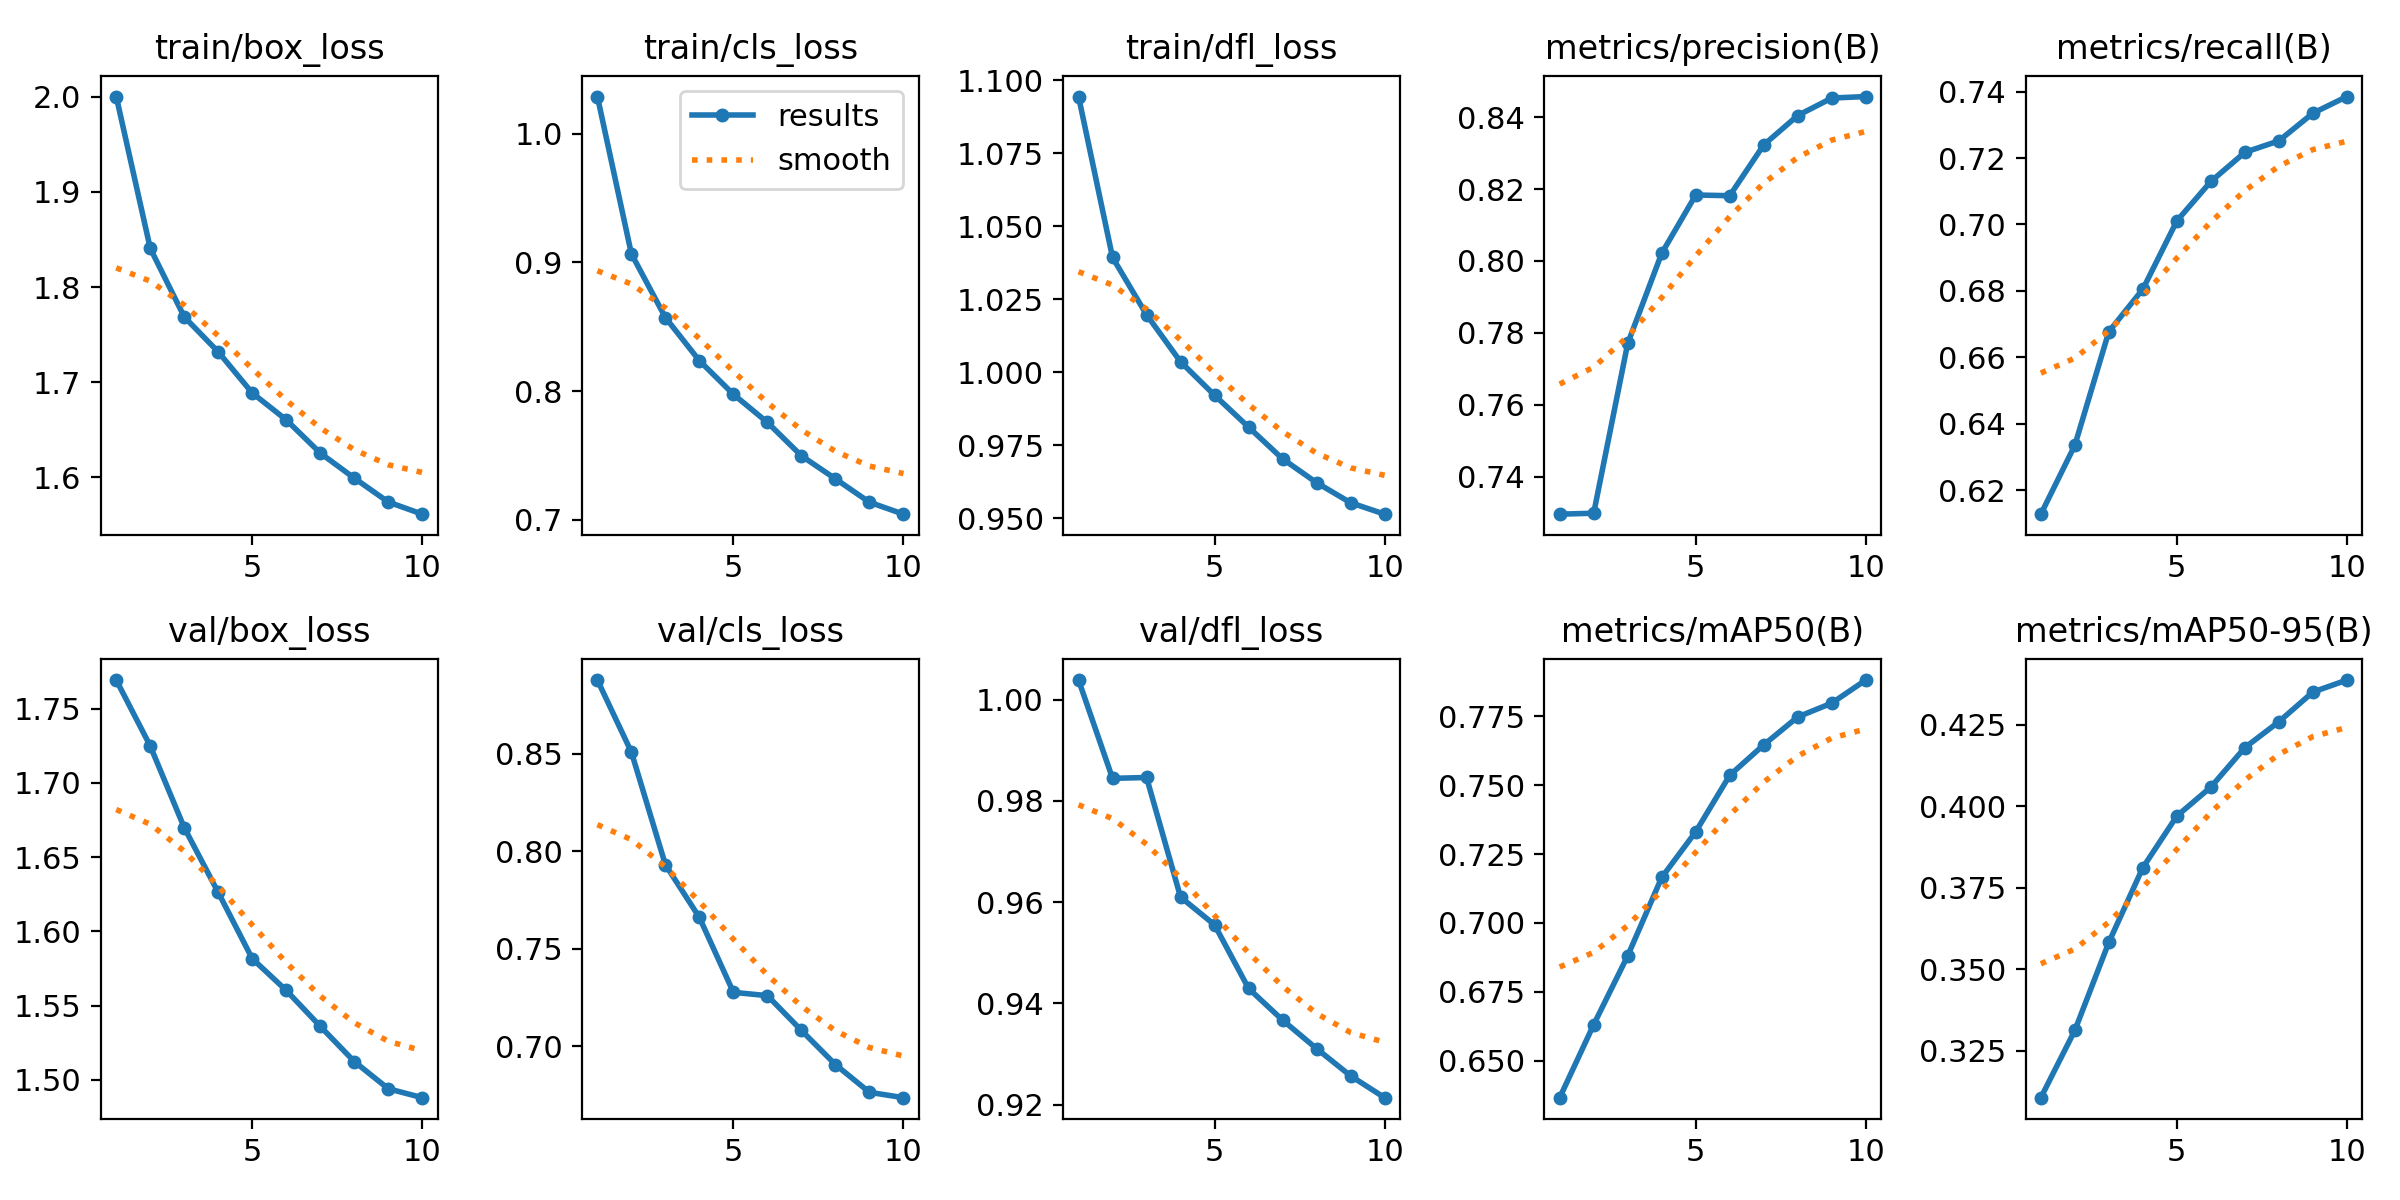

confusion_matrix.png


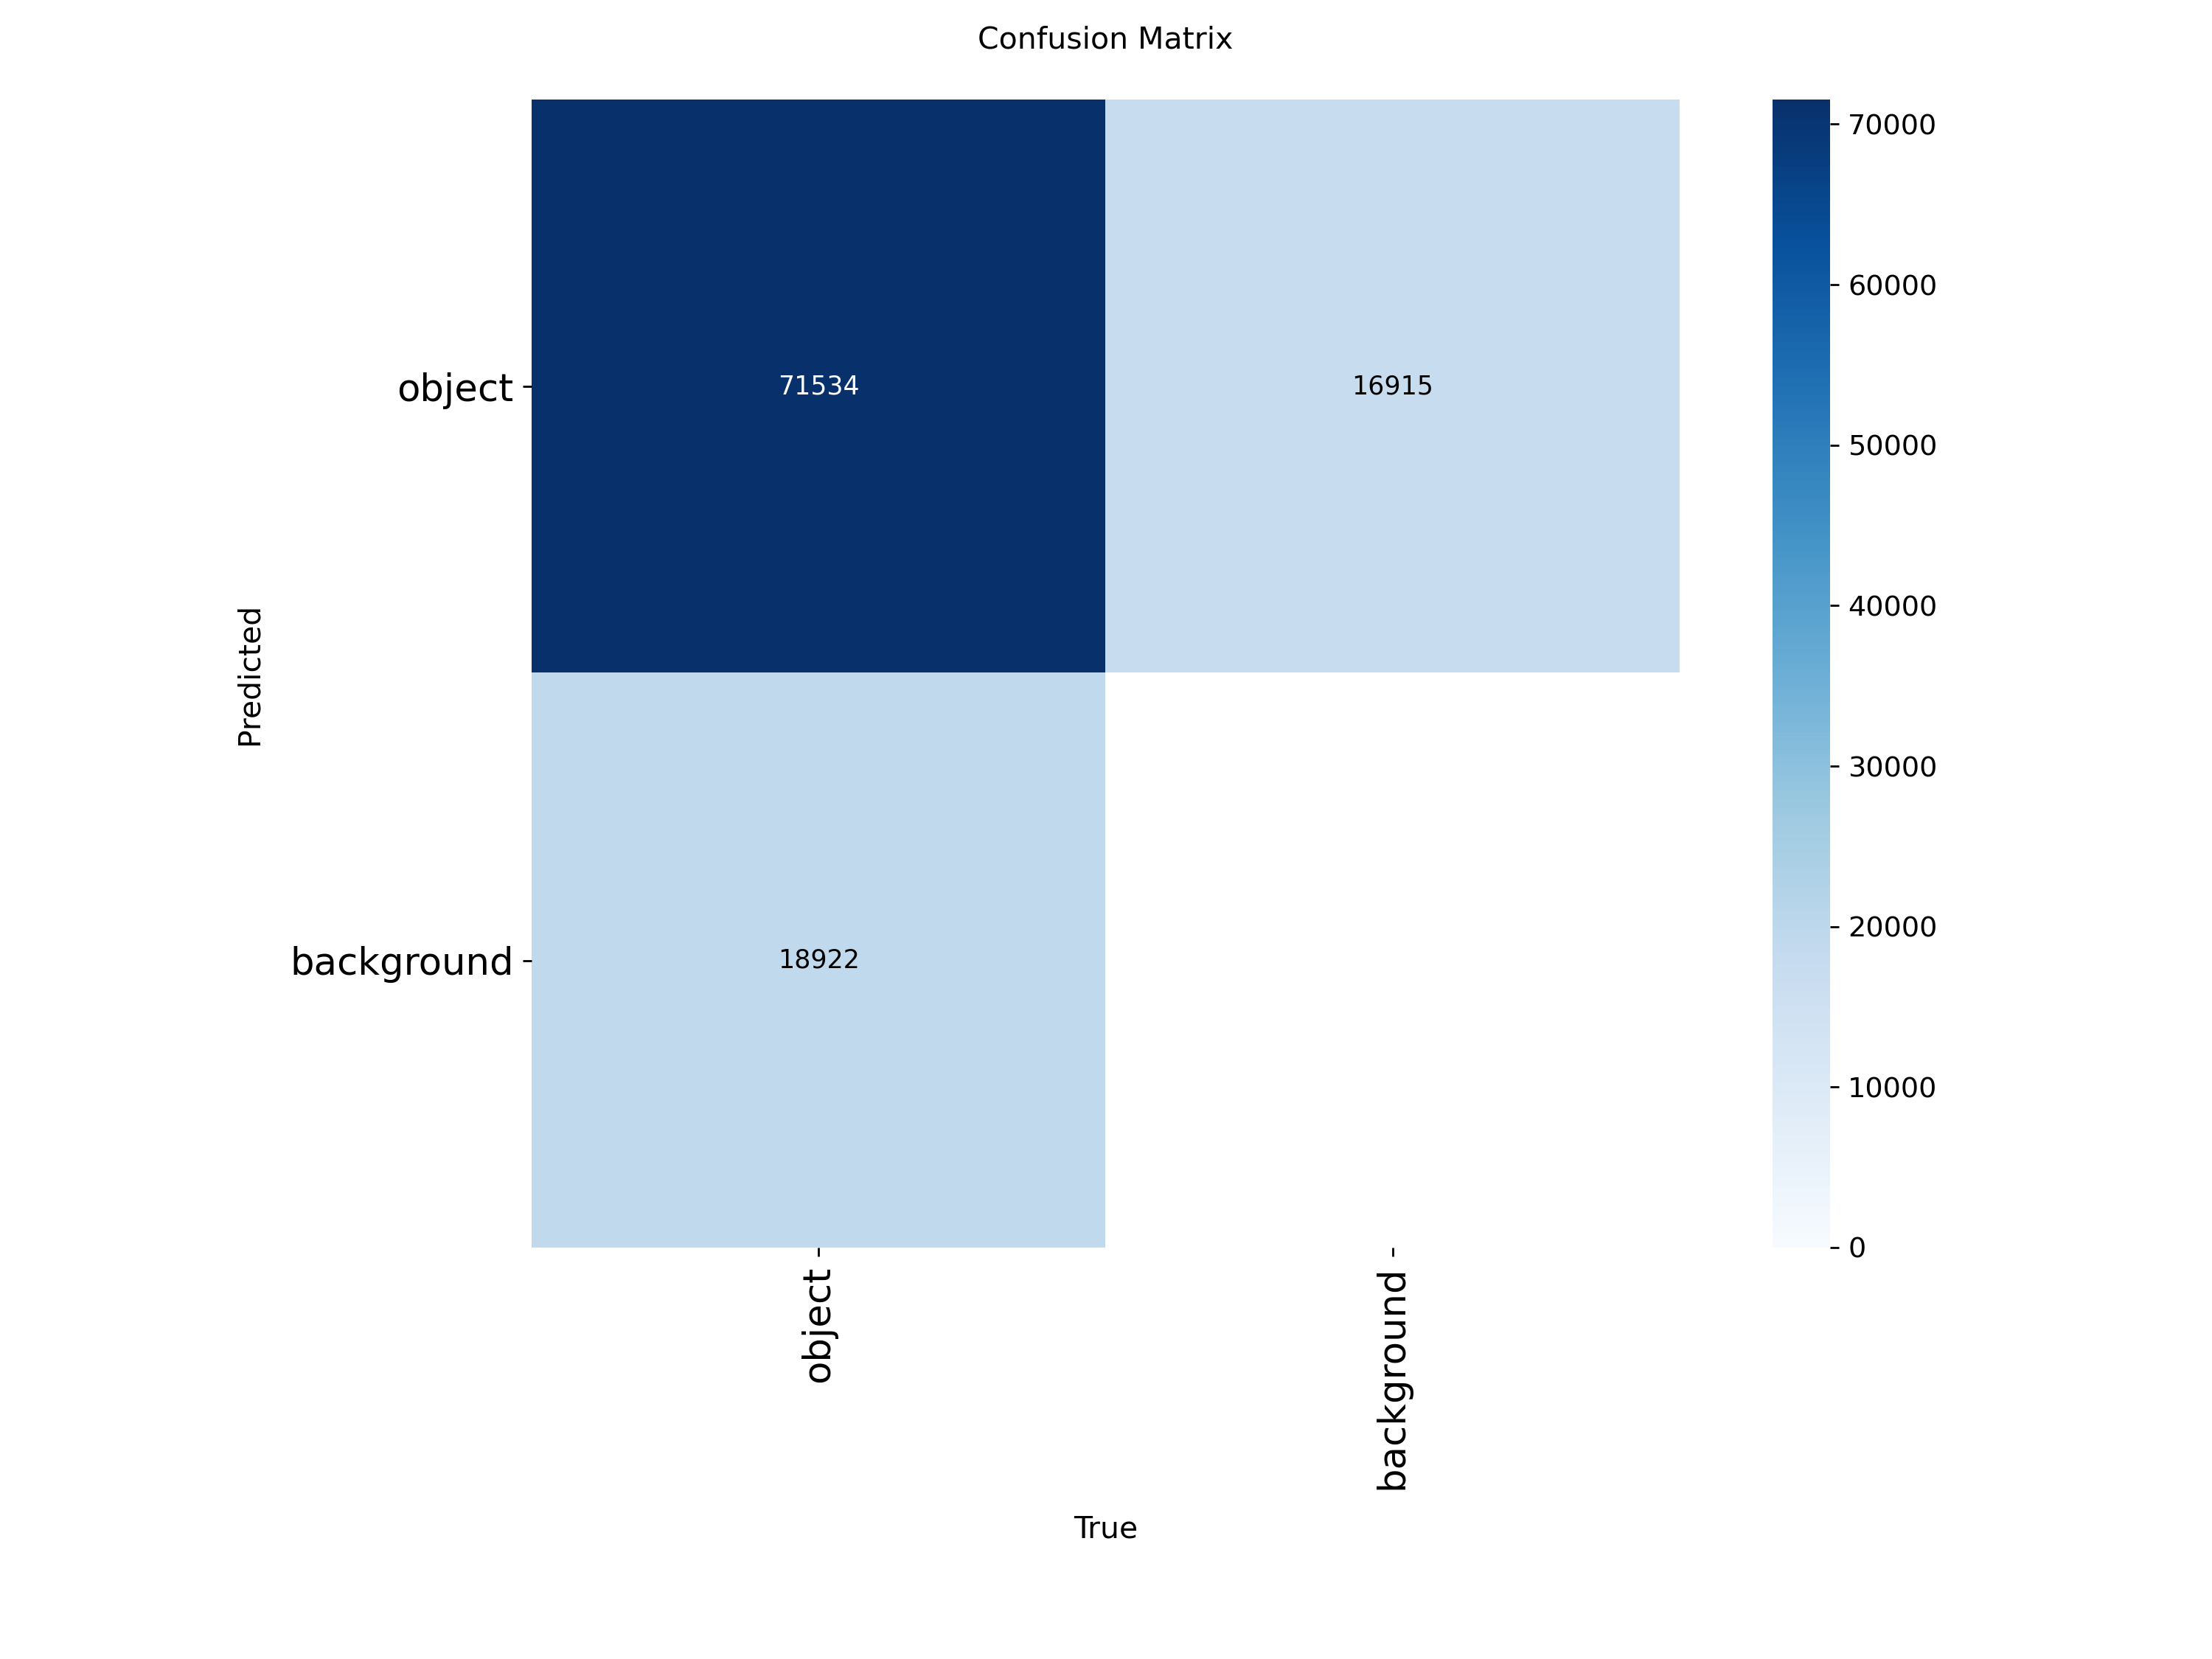

In [38]:
# ============================================================
# Display Training Curves
# ============================================================

from IPython.display import Image, display
from pathlib import Path

RESULTS_DIR = Path("/kaggle/working/RetailBrain_Models/YOLOv8n_Baseline")

images = [

    "results.png",

    "PR_curve.png",

    "P_curve.png",

    "R_curve.png",

    "F1_curve.png",

    "confusion_matrix.png"

]

for img in images:

    file = RESULTS_DIR / img

    if file.exists():

        print(img)

        display(Image(filename=str(file)))

In [39]:
# ============================================================
# Training Results
# ============================================================

import pandas as pd

results_csv = RESULTS_DIR / "results.csv"

history = pd.read_csv(results_csv)

history.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,154.319,2.00022,1.02897,1.09435,0.72952,0.61286,0.63651,0.31057,1.76934,0.88772,1.00389,0.003332,0.003332,0.070015
1,2,296.723,1.84071,0.90665,1.03926,0.72979,0.63360,0.66305,0.33124,1.72491,0.85074,0.98447,0.006504,0.006504,0.039853
2,3,437.216,1.76863,0.85711,1.01966,0.77704,0.66778,0.68804,0.35828,1.66991,0.79298,0.98464,0.009053,0.009053,0.009069
3,4,575.668,1.73186,0.82356,1.00356,0.80213,0.68055,0.71649,0.38120,1.62625,0.76593,0.96101,0.007960,0.007960,0.007960
4,5,713.906,1.68868,0.79742,0.99211,0.81836,0.70109,0.73307,0.39703,1.58167,0.72753,0.95553,0.006580,0.006580,0.006580


In [40]:
# ============================================================
# Best Epoch
# ============================================================

best_epoch = history["metrics/mAP50(B)"].idxmax()

print("Best Epoch :", best_epoch)

print(history.loc[best_epoch])

Best Epoch : 9
epoch                     10.000000
time                    1426.130000
train/box_loss             1.561340
train/cls_loss             0.704220
train/dfl_loss             0.951400
metrics/precision(B)       0.845760
metrics/recall(B)          0.738490
metrics/mAP50(B)           0.788180
metrics/mAP50-95(B)        0.438770
val/box_loss               1.488060
val/cls_loss               0.673500
val/dfl_loss               0.921390
lr/pg0                     0.000342
lr/pg1                     0.000342
lr/pg2                     0.000342
Name: 9, dtype: float64


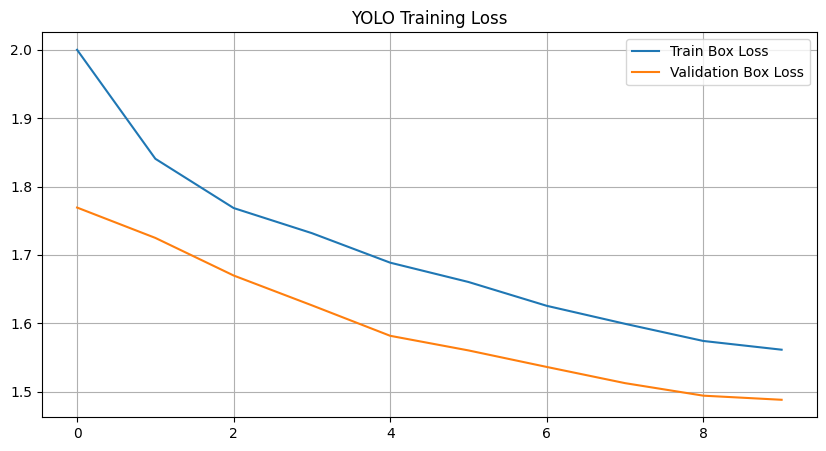

In [41]:
# ============================================================
# Plot Loss
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history["train/box_loss"],label="Train Box Loss")

plt.plot(history["val/box_loss"],label="Validation Box Loss")

plt.legend()

plt.grid()

plt.title("YOLO Training Loss")

plt.show()

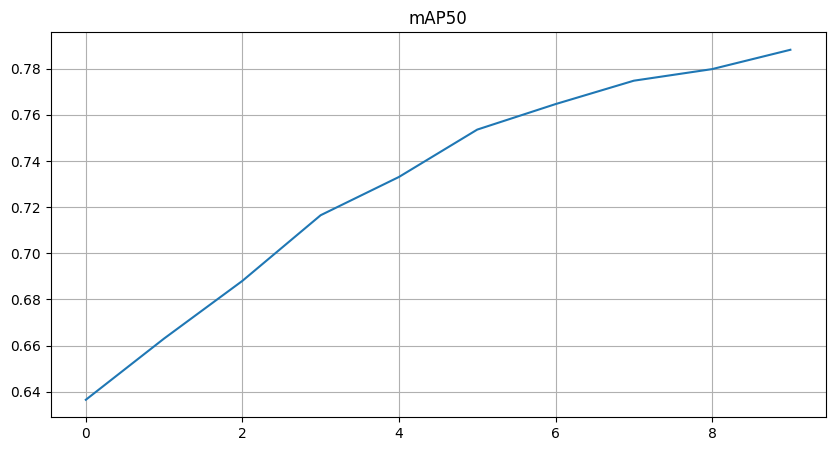

In [42]:
# ============================================================
# Plot mAP50
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history["metrics/mAP50(B)"])

plt.title("mAP50")

plt.grid()

plt.show()

In [43]:
# ============================================================
# Model Information
# ============================================================

print("="*60)

print("Model :",MODEL)

print("Dataset : SKU110K")

print("Epochs :",EPOCHS)

print("Batch :",BATCH_SIZE)

print("Image Size :",IMG_SIZE)

print("Optimizer : AdamW")

print("="*60)

Model : yolov8n.pt
Dataset : SKU110K
Epochs : 10
Batch : 4
Image Size : 416
Optimizer : AdamW


In [50]:
# ============================================================
# Save Files
# ============================================================

import shutil

EXPORT_DIR = Path("/kaggle/working/Final_Model")

EXPORT_DIR.mkdir(exist_ok=True)

files = [

RESULTS_DIR/"weights"/"best.pt",

RESULTS_DIR/"weights"/"last.pt",

RESULTS_DIR/"results.csv",

RESULTS_DIR/"results.png",

RESULTS_DIR/"PR_curve.png",

RESULTS_DIR/"P_curve.png",

RESULTS_DIR/"R_curve.png",

RESULTS_DIR/"F1_curve.png",

RESULTS_DIR/"confusion_matrix.png"

]

for file in files:

    if file.exists():

        shutil.copy(file,EXPORT_DIR)

print("Files Saved Successfully")

Files Saved Successfully


In [52]:
# ============================================================
# Exported Files
# ============================================================

for file in EXPORT_DIR.iterdir():

    print(file.name)

confusion_matrix.png
best.pt
results.png
last.pt
results.csv


In [74]:
# ============================================================
# Final Summary
# ============================================================

print("="*70)

print("Notebook 04 Completed Successfully")

print("="*70)

print("YOLOv8 Nano Baseline Training Finished")

print("Dataset : SKU110K")

print("Results Folder :",RESULTS_DIR)

print("Export Folder :",EXPORT_DIR)

print("="*70)

Notebook 04 Completed Successfully
YOLOv8 Nano Baseline Training Finished
Dataset : SKU110K
Results Folder : /kaggle/working/RetailBrain_Models/YOLOv8n_Baseline
Export Folder : /kaggle/working/Final_Model
